# Import libraries

In [61]:
import numpy as np
import scipy as scp
import matplotlib.pyplot as plt
import emcee
import corner

# Define constants

In [62]:
c = 299792458 * 10**(-3)
#H0 = 75
f0 = 6.61* 10**-9 * 10**(-7) * (3.2408*10**(-25))**(-2)

# Some key functions

In [63]:
#order of variables: z, k, omega_M, omega_DE, LPeakLambda, rc

def scale_factor(z):
    return 1/(1+z)

def Friedmann_eq(z, omega_DE, H0):
    a = scale_factor(z)
    omega_M = 1 - omega_DE
    H2 = (H0**2)*(omega_M/(a**3) + omega_DE)
    return np.sqrt(H2)

def integrand(z, omega_DE, H0):
    return c/Friedmann_eq(z, omega_DE, H0)

def co_moving_dist(z, omega_DE, H0):
    z_up = np.concatenate(([0], z))
    r_cm = scp.integrate.odeint(lambda y, t: integrand(t, omega_DE, H0), 0, z_up)
    r_c = np.delete(r_cm, 0)
    return np.ndarray.flatten(r_c)

def dist_modulus(z, omega_DE, H0):
    rc = co_moving_dist(z, omega_DE, H0)
    dl = (1+z)*rc
    dist_mod = 5*np.log10(dl) + 25
    return dist_mod


def mag_model(z, omega_DE, LPeakLambda):
    rc = co_moving_dist(z, omega_DE)
    flux = (1e32)*LPeakLambda/(4*np.pi*((rc*(1+z))**2))
    argument = flux/f0
    mag = -2.5*np.log10(argument)
    return mag

In [64]:
#alt_rc([0,1,2,5,8], 0.7)
"""array([[0.        ],
       [0.77142711],
       [1.20947123],
       [1.8155091 ],
       [2.08819249]])"""

'array([[0.        ],\n       [0.77142711],\n       [1.20947123],\n       [1.8155091 ],\n       [2.08819249]])'

# Load the data

In [65]:
sn_z, sn_z_err, sn_mu, = np.loadtxt("pantheon-plus+SH0ES-SN.txt", usecols=(2,3,4), unpack = True)
sort_IDs = np.argsort(sn_z)
sn_z = sn_z[sort_IDs]
sn_mu = sn_mu[sort_IDs]
sn_z_err = sn_z_err[sort_IDs]
covmat_file = np.loadtxt("Pantheon+SH0ES_STAT+SYS.cov")
covmat_file_dim = int(covmat_file[0])
covmat_file = np.delete(covmat_file, 0)
covmat = np.zeros((covmat_file_dim, covmat_file_dim))
covmat.shape
for i in range(covmat_file_dim):
    covmat[i] = covmat_file[i*covmat_file_dim:(i+1)*covmat_file_dim]
covmat_inv = np.linalg.inv(covmat)

## Priors

Parameters of model are: {k, H0, omega_M, omega_DE, LPeakLambda}

Priors are: {k=0, H0~70, etc}

Should priors be uniform or Gaussian over the range? - use uniform unless I have good reasons to use a Gaussian (eg if I use the Planck result as a prior, the prior could be a Gaussian with st dev being the error given by Planck)

In [66]:
def log_prior(theta):
    omega_DE, H0 = theta
    if 0<omega_DE<1 and 50<H0<80:
        return 0.0
    return -np.inf

priors_central = [0.5, 75]
    

# Likelihood function

In [67]:
def log_likelihood(theta, z, mu, covmatrix_inv):
    omega_DE, H0 = theta
    model = dist_modulus(z, omega_DE, H0)
    resids = mu - model
    chi2 = np.dot(np.dot(resids, covmatrix_inv), resids)
    return -0.5*chi2


def log_probability(theta, z, mu, covmatrix_inv):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, z, mu, covmatrix_inv)


# The MCMC algorithm

Questions to investigate: how many chains should I discard? What is burn in? How many walkers do I need? How many steps should the walkers take?

In [69]:
pos = priors_central + 0.1*np.random.randn(20, 2)
nsteps = 50 #number of steps walkers take
nwalkers, ndim = pos.shape
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args = (sn_z, sn_mu, covmat_inv)
)
sampler.run_mcmc(pos, nsteps, progress = True)

100%|██████████| 50/50 [00:01<00:00, 40.92it/s]


State([[4.35790329e-02 7.69284045e+01]
 [6.58679592e-02 7.85507841e+01]
 [6.96634998e-02 7.95745361e+01]
 [2.83361450e-02 7.64596213e+01]
 [5.11953502e-04 7.69572524e+01]
 [4.86178379e-02 7.70164014e+01]
 [1.17528271e-01 7.70783892e+01]
 [3.15973609e-02 7.71288279e+01]
 [2.51156528e-02 7.88185534e+01]
 [1.09350442e-01 7.96128117e+01]
 [8.54101585e-04 7.78258512e+01]
 [1.78353272e-01 7.98069111e+01]
 [4.01462686e-02 7.60259403e+01]
 [1.57895056e-02 7.66836666e+01]
 [8.63730647e-02 7.79492505e+01]
 [3.51346555e-02 7.63600379e+01]
 [2.15039471e-01 7.96171605e+01]
 [1.33361133e-02 7.72793738e+01]
 [1.91983358e-02 7.94873663e+01]
 [4.87601564e-03 7.71423477e+01]], log_prob=[-54756177.4171316  -54640829.80464651 -54562793.72374523
 -54784370.77123137 -54726112.16728686 -54752337.64994055
 -54792958.58626904 -54732206.3460374  -54593175.72546582
 -54586114.38757166 -54656473.83111475 -54617926.1856254
 -54827461.64217369 -54758065.39031367 -54702188.85551962
 -54796888.1100169  -54658364.5014

AutocorrError: The chain is shorter than 50 times the integrated autocorrelation time for 2 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 1;
tau: [6.24451581 6.78341848]

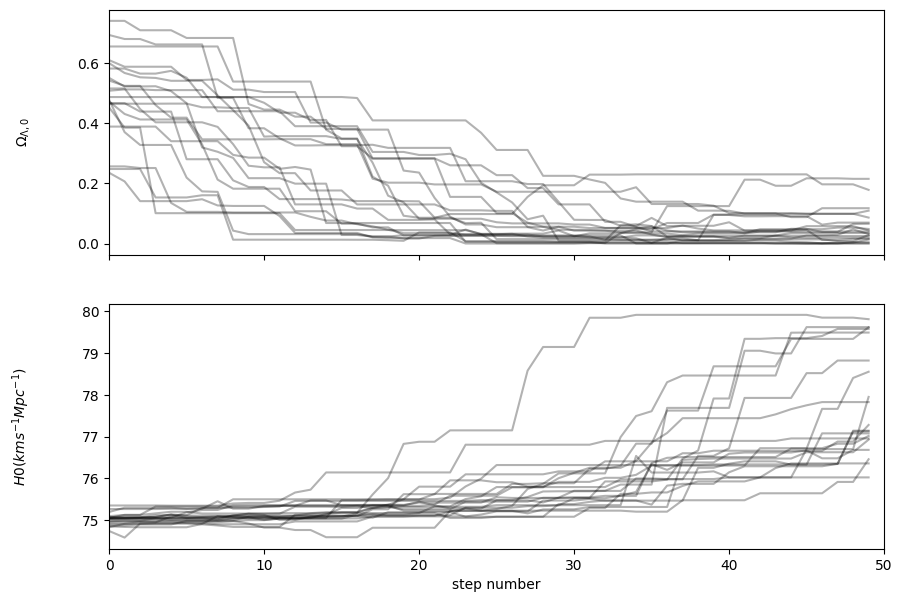

In [70]:
ndiscard = 5  #how many steps at the beginning of the chain to discard
flat_samples = sampler.get_chain(discard = ndiscard, thin = 15, flat = True)

fig, axes = plt.subplots(2, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels = ["${Ω_{Λ,0}}$", "$H0 (kms^{-1}Mpc^{-1})$"] 
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

print(sampler.get_autocorr_time())

# Covariance plots

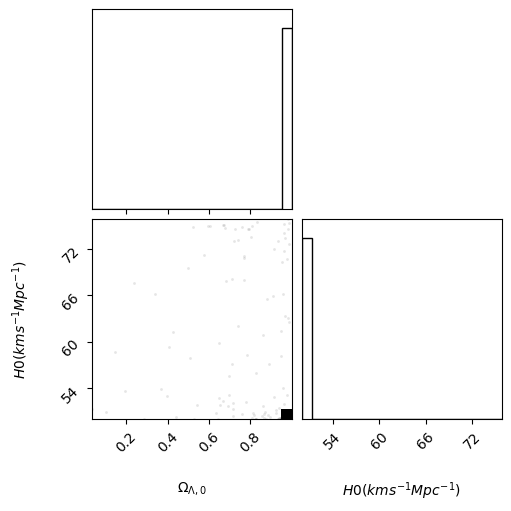

In [ ]:

fig = corner.corner(
    flat_samples, labels = labels
)
plt.savefig("corner.png")

In [ ]:


for i in range(ndim):
    mcmc = np.percentile(flat_samples[:, i], [34, 50, 68])
    q = np.diff(mcmc)
    print(f"{labels[i]}: {mcmc[1]}, {q[0]}, {q[1]}")

${Ω_{Λ,0}}$: 0.9999953179731478, 2.7566340013995827e-06, 2.1730525467944517e-06
$H0 (kms^{-1}Mpc^{-1})$: 50.00003977942879, 1.6541710984085967e-05, 2.7522199047780305e-05
